# ViCAM - Viral fine-tuning of Cambriam

In [ ]:
from Bio import SeqIO

In [5]:
#input_fasta = "../data/raw/URVDBv29-prot_clustered.fasta"
input_fasta = "../data/processed/C-RVDBv29_no_poly/train.fasta"

records = list(SeqIO.parse(input_fasta, "fasta"))

#records = [record for record in records if 'poly' in record.description]

In [6]:
len(records)

568485

In [7]:
mn=0
mx=0
for record in records:
    if len(record.seq) < mn or mn == 0:
        mn = len(record.seq)
    if len(record.seq) > mx:
        mx = len(record.seq)
print(f"Min length: {mn}")
print(f"Max length: {mx}")


Min length: 11
Max length: 2047


In [ ]:
count = 0
while count < 10:
    record = records[count]
    print(record.description)
    count += 1

acc|GENBANK|UJJ65121.1|GENBANK|OM336640|surface glycoprotein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65122.1|GENBANK|OM336640|ORF3a protein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65123.1|GENBANK|OM336640|envelope protein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65124.1|GENBANK|OM336640|membrane glycoprotein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65125.1|GENBANK|OM336640|ORF6 protein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65126.1|GENBANK|OM336640|ORF7a protein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65127.1|GENBANK|OM336640|ORF7b [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65128.1|GENBANK|OM336640|ORF8 protein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65129.1|GENBANK|OM336640|nucleocapsid phosphoprotein [Severe acute respiratory syndrome coronavirus 2]
acc|GENBANK|UJJ65130.1|GENBANK|OM336640|OR

In [ ]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

def filter_fasta_by_valid_amino_acids(input_fasta_path, output_fasta_path):
    """
    Filters a FASTA file to keep only sequences with valid amino acids.

    Args:
        input_fasta_path (str): Path to the input FASTA file.
        output_fasta_path (str): Path to save the filtered FASTA file.
    """
    valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")
    
    valid_records = []
    for record in SeqIO.parse(input_fasta_path, "fasta"):
        sequence_str = str(record.seq).upper()
        is_valid = True
        for aa in sequence_str:
            if aa not in valid_amino_acids:
                is_valid = False
                print(f"Invalid character '{aa}' found in sequence: {record.id}. Skipping.")
                break
        if is_valid:
            valid_records.append(record)

    SeqIO.write(valid_records, output_fasta_path, "fasta")
    print(f"Filtered FASTA saved to: {output_fasta_path}")
    print(f"Original records: {len(list(SeqIO.parse(input_fasta_path, 'fasta')))}, Valid records: {len(valid_records)}")

# Example usage:
input_file = "../data/processed/C-RVDBv29_no_poly/train.fasta"
output_file = "../data/processed/C-RVDBv29_no_poly_20aa/train.fasta"
filter_fasta_by_valid_amino_acids(input_file, output_file)

In [4]:
[x for x in ['vicam_300m', 'vicam_600m','esmc_300m', 'esmc_600m'] if x in '/chpc/home/C-RVDBv29_no_poly/vicam_600m.fasta'][0]

'vicam_600m'

# Resume training

In [19]:
checkpoint = torch.load('../checkpoints/ViCAM_300M/CRVDBv29_maxlen2046/epoch=6-val_loss=1.50.ckpt')

In [20]:
checkpoint.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers'])

In [21]:
checkpoint['optimizer_states'][0]['param_groups']

[{'lr': 1e-06,
  'betas': (0.9, 0.95),
  'eps': 1e-08,
  'weight_decay': 0.01,
  'amsgrad': False,
  'maximize': False,
  'foreach': None,
  'capturable': False,
  'differentiable': False,
  'fused': None,
  'decoupled_weight_decay': True,
  'params': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   1

# Inference

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import torch
from esm.models.esmc import ESMC
from esm.tokenization import get_esmc_model_tokenizers

tokenizer = get_esmc_model_tokenizers()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
model_path= '/stor/work/Wilke/wilkelab/pLMs_checkpoints/ESMC/esmc_300m_2024_12_v0.pth'
state_dict = torch.load(model_path, map_location=device, weights_only=True)
esmc300m = ESMC(d_model=960, n_heads=15, n_layers=30, tokenizer=get_esmc_model_tokenizers())
esmc300m.load_state_dict(state_dict)
esmc300m.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
esmc300m.to(device)
esmc300m

ESMC(
  (embed): Embedding(64, 960)
  (transformer): TransformerStack(
    (blocks): ModuleList(
      (0-29): 30 x UnifiedTransformerBlock(
        (attn): MultiHeadAttention(
          (layernorm_qkv): Sequential(
            (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=960, out_features=2880, bias=False)
          )
          (out_proj): Linear(in_features=960, out_features=960, bias=False)
          (q_ln): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (k_ln): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (rotary): RotaryEmbedding()
        )
        (ffn): Sequential(
          (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (1): Linear(in_features=960, out_features=5120, bias=False)
          (2): SwiGLU()
          (3): Linear(in_features=2560, out_features=960, bias=False)
        )
      )
    )
    (norm): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
  )
  (sequ

In [3]:
for name, param in esmc300m.named_parameters():
    print(name, param.requires_grad)

embed.weight True
transformer.blocks.0.attn.layernorm_qkv.0.weight True
transformer.blocks.0.attn.layernorm_qkv.0.bias True
transformer.blocks.0.attn.layernorm_qkv.1.weight True
transformer.blocks.0.attn.out_proj.weight True
transformer.blocks.0.attn.q_ln.weight True
transformer.blocks.0.attn.k_ln.weight True
transformer.blocks.0.ffn.0.weight True
transformer.blocks.0.ffn.0.bias True
transformer.blocks.0.ffn.1.weight True
transformer.blocks.0.ffn.3.weight True
transformer.blocks.1.attn.layernorm_qkv.0.weight True
transformer.blocks.1.attn.layernorm_qkv.0.bias True
transformer.blocks.1.attn.layernorm_qkv.1.weight True
transformer.blocks.1.attn.out_proj.weight True
transformer.blocks.1.attn.q_ln.weight True
transformer.blocks.1.attn.k_ln.weight True
transformer.blocks.1.ffn.0.weight True
transformer.blocks.1.ffn.0.bias True
transformer.blocks.1.ffn.1.weight True
transformer.blocks.1.ffn.3.weight True
transformer.blocks.2.attn.layernorm_qkv.0.weight True
transformer.blocks.2.attn.layernor

In [18]:
tokens = tokenizer(["AAAAAAA", "AAAAA"], return_tensors="pt", padding=True)
tokens.to(device) 

{'input_ids': tensor([[0, 5, 5, 5, 5, 5, 5, 5, 2],
        [0, 5, 5, 5, 5, 5, 2, 1, 1]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0]], device='cuda:0')}

In [19]:
esmc300m(tokens["input_ids"])

ESMCOutput(sequence_logits=tensor([[[-38.0333, -38.0360, -38.0323,  ..., -38.0285, -38.0664, -38.0540],
         [-40.2790, -40.2907, -40.3479,  ..., -40.3142, -40.3002, -40.3140],
         [-36.3614, -36.3531, -36.3800,  ..., -36.4196, -36.3916, -36.4265],
         ...,
         [-36.4638, -36.4345, -36.5000,  ..., -36.5169, -36.4898, -36.5214],
         [-35.7786, -35.7601, -35.8030,  ..., -35.8089, -35.8304, -35.8100],
         [-33.7242, -33.7013, -33.7387,  ..., -33.7467, -33.7438, -33.7541]],

        [[-38.0487, -38.0396, -38.0528,  ..., -38.0591, -38.0906, -38.0756],
         [-40.0131, -40.0105, -40.0686,  ..., -40.0690, -40.0437, -40.0478],
         [-36.1433, -36.1190, -36.1505,  ..., -36.2211, -36.2072, -36.1873],
         ...,
         [-32.9298, -32.9026, -32.9321,  ..., -32.9482, -32.9679, -32.9473],
         [-19.2742, -19.4478, -19.2775,  ..., -19.3356, -19.1872, -19.4463],
         [-19.2742, -19.4478, -19.2775,  ..., -19.3356, -19.1872, -19.4463]]],
       device='cu

In [ ]:
path_checkpoint = "/stor/work/Wilke/luiz/ViCAM/checkpoints/ViCAM_300M/v03_no_ploy/epoch=1-val_loss=1.73.ckpt"
state_dict = torch.load(path_checkpoint)["state_dict"]
new_state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}
vicam = ESMC(d_model=960, n_heads=15, n_layers=30, tokenizer=get_esmc_model_tokenizers())
vicam.load_state_dict(new_state_dict)
vicam.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vicam.to(device)
vicam


ESMC(
  (embed): Embedding(64, 960)
  (transformer): TransformerStack(
    (blocks): ModuleList(
      (0-29): 30 x UnifiedTransformerBlock(
        (attn): MultiHeadAttention(
          (layernorm_qkv): Sequential(
            (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=960, out_features=2880, bias=False)
          )
          (out_proj): Linear(in_features=960, out_features=960, bias=False)
          (q_ln): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (k_ln): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (rotary): RotaryEmbedding()
        )
        (ffn): Sequential(
          (0): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
          (1): Linear(in_features=960, out_features=5120, bias=False)
          (2): SwiGLU()
          (3): Linear(in_features=2560, out_features=960, bias=False)
        )
      )
    )
    (norm): LayerNorm((960,), eps=1e-05, elementwise_affine=True)
  )
  (sequ

# Testing model embeddings

In [1]:
import torch
import pandas as pd
import numpy as np

from scipy import stats
from sklearn import metrics
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore') 
from sklearn.exceptions import ConvergenceWarning

In [2]:
def features_scaler(features):
    '''Scale the features by min-max scaler, to ensure that the features selected by Lasso are not biased by the scale of the features'''
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_features = scaler.fit_transform(features)
    return pd.DataFrame(scaled_features)


def run_regression(features, target):
    '''this version computes y_pred for train and test sets'''
    # Initialize lists for storing results
    folds, num_nonzero_coefs = [], []
    r2s_train, maes_train, rmses_train = [], [], []
    r2s_test, maes_test, rmses_test = [], [], []
    rhos_train, rhos_test = [], []

    # Define the KFold cross-validator
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Loop over the KFold splits
    for kfold, (train_index, test_index) in enumerate(kf.split(features)):
        # Split the data into training and testing sets
        X_train, X_test = features.iloc[train_index], features.iloc[test_index]
        y_train, y_test = target.iloc[train_index], target.iloc[test_index]

        # Define and train the regression model
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            model = LassoCV(max_iter=1000, tol=1e-2, n_jobs=-1)
            model.fit(X_train, y_train)

            # get the number of non-zero coefficients
            coeficients = model.coef_
            num_nonzero_coef = np.sum(coeficients != 0)

            # Make predictions
            y_pred_train = pd.DataFrame(model.predict(X_train))
            y_pred_test = pd.DataFrame(model.predict(X_test))

            # Evaluate the model
            r2_train = metrics.r2_score(y_train, y_pred_train)
            mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
            mse_train = metrics.mean_squared_error(y_train, y_pred_train)
            rmse_train = np.sqrt(mse_train)
            rho_train, p_value_train = spearmanr(y_train, y_pred_train)

            r2_test = metrics.r2_score(y_test, y_pred_test)
            mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
            mse_test = metrics.mean_squared_error(y_test, y_pred_test)
            rmse_test = np.sqrt(mse_test)
            rho_test, p_value_test = spearmanr(y_test, y_pred_test)

            # Append results
            r2s_train.append(r2_train)
            maes_train.append(mae_train)
            rmses_train.append(rmse_train)
            rhos_train.append(rho_train)

            r2s_test.append(r2_test)
            maes_test.append(mae_test)
            rmses_test.append(rmse_test)
            rhos_test.append(rho_test)


            folds.append(kfold + 1)
            num_nonzero_coefs.append(num_nonzero_coef)

        # Return the collected results
        print(f"Results:  fold {kfold}, r2_train: {r2_train:.3f}, r2_test: {r2_test:.3f}, Num coefs: {num_nonzero_coef}")
    print(f"Results:  r2_train: {np.mean(r2s_train):.2f}, r2_test: {np.mean(r2s_test):.2f}, Num coefs: {np.mean(num_nonzero_coefs):.2f}")
    return r2s_train, maes_train, rmses_train, r2s_test, maes_test, rmses_test, rhos_train, rhos_test, folds, num_nonzero_coefs


## ESM C 300M

In [4]:
metadata = pd.read_csv("../data/DMS_mut_metadata/PA_FLU_Sun2015_metadata.csv", index_col=0)  

embeddings = pd.DataFrame(torch.load('../embeddings/esmc_300m/PA_FLU_Sun2015_embeddings.pt')).T
embeddings.reset_index(inplace=True)
embeddings.rename(columns={"index": "ID"}, inplace=True)


data = metadata.merge(embeddings, how='inner', left_on='ID', right_on='ID')
target = data['target']
features = data.iloc[:, metadata.shape[1]:]
features = features_scaler(features)
print(features.shape)
print(target.shape)
data

(2590, 960)
(2590,)


,ID,mutant,target,sequence,0,1,2,3,4,5,...,950,951,952,953,954,955,956,957,958,959
0,PA_FLU_C8R,C8R,0.120065,MEDFVRQRFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001842,0.001954,0.010462,0.012958,0.003278,0.003426,...,0.000652,-0.012437,-0.007702,0.002752,-0.004459,0.009886,0.003699,-0.003755,-0.006035,-0.007248
1,PA_FLU_C8Y,C8Y,0.869537,MEDFVRQYFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001988,0.002019,0.010245,0.012934,0.003225,0.003475,...,0.000601,-0.012689,-0.007409,0.002945,-0.004173,0.009672,0.003122,-0.003733,-0.006044,-0.007270
2,PA_FLU_C8C,C8C,0.426665,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001767,0.001509,0.010462,0.012814,0.003647,0.003377,...,0.000815,-0.012426,-0.006838,0.002727,-0.004453,0.010092,0.003475,-0.004122,-0.006680,-0.007045
3,PA_FLU_F9L,F9L,0.119464,MEDFVRQCLNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001603,0.001408,0.010345,0.012646,0.003834,0.003286,...,0.000857,-0.012337,-0.006629,0.002766,-0.004546,0.010311,0.003645,-0.004141,-0.006735,-0.007024
4,PA_FLU_F9S,F9S,0.078119,MEDFVRQCSNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001810,0.001537,0.010888,0.012893,0.003228,0.003209,...,0.000773,-0.012788,-0.006652,0.002718,-0.004526,0.010168,0.003424,-0.003940,-0.006996,-0.007344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,PA_FLU_L715L,L715L,1.394932,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001767,0.001509,0.010462,0.012814,0.003647,0.003377,...,0.000815,-0.012426,-0.006838,0.002727,-0.004453,0.010092,0.003475,-0.004122,-0.006680,-0.007045
2586,PA_FLU_L715S,L715S,0.914543,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001683,0.001725,0.010480,0.012886,0.003553,0.003232,...,0.000785,-0.012572,-0.006956,0.002753,-0.004591,0.010266,0.003608,-0.004101,-0.006722,-0.007024
2587,PA_FLU_L715L,L715L,0.446139,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001767,0.001509,0.010462,0.012814,0.003647,0.003377,...,0.000815,-0.012426,-0.006838,0.002727,-0.004453,0.010092,0.003475,-0.004122,-0.006680,-0.007045
2588,PA_FLU_R716G,R716G,0.777810,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,0.001630,0.001480,0.010464,0.013056,0.003677,0.003463,...,0.000961,-0.012293,-0.006662,0.002908,-0.004706,0.010195,0.003459,-0.004245,-0.006762,-0.007140


In [5]:
r2s_train, maes_train, rmses_train, r2s_test, maes_test, rmses_test, rhos_train, rhos_test, folds, num_nonzero_coefs = run_regression(features, target)

Results:  fold 0, r2_train: 0.042, r2_test: 0.048, Num coefs: 20
Results:  fold 1, r2_train: 0.024, r2_test: 0.009, Num coefs: 13
Results:  fold 2, r2_train: 0.057, r2_test: 0.019, Num coefs: 23
Results:  fold 3, r2_train: 0.055, r2_test: 0.020, Num coefs: 17
Results:  fold 4, r2_train: 0.039, r2_test: -0.004, Num coefs: 17
Results:  r2_train: 0.04, r2_test: 0.02, Num coefs: 18.00


## ViCam 300M

In [6]:
metadata = pd.read_csv("../data/DMS_mut_metadata/PA_FLU_Sun2015_metadata.csv", index_col=0)  

embeddings = pd.DataFrame(torch.load('../embeddings/ViCAM/CRVDBv29_maxLen2046_20aa_Full_RLRP_lr1e6/PA_FLU_Sun2015_embeddings.pt')).T
embeddings.reset_index(inplace=True)
embeddings.rename(columns={"index": "ID"}, inplace=True)


data = metadata.merge(embeddings, how='inner', left_on='ID', right_on='ID')
target = data['target']
features = data.iloc[:, metadata.shape[1]:]
features = features_scaler(features)
print(features.shape)
print(target.shape)
data

(2590, 960)
(2590,)


,ID,mutant,target,sequence,0,1,2,3,4,5,...,950,951,952,953,954,955,956,957,958,959
0,PA_FLU_C8R,C8R,0.120065,MEDFVRQRFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013247,-0.010101,0.023480,0.002337,-0.001124,0.005009,...,0.018639,-0.008886,0.013687,-0.019884,0.001898,-0.023449,0.017373,0.027590,-0.017641,-0.019547
1,PA_FLU_C8Y,C8Y,0.869537,MEDFVRQYFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013141,-0.009944,0.024252,0.002449,-0.001213,0.004920,...,0.018804,-0.008841,0.013915,-0.020125,0.001923,-0.023644,0.017589,0.027543,-0.017581,-0.019518
2,PA_FLU_C8C,C8C,0.426665,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013106,-0.009913,0.024420,0.002670,-0.001244,0.004936,...,0.018669,-0.009142,0.013780,-0.020471,0.001566,-0.023689,0.017695,0.027663,-0.017613,-0.019305
3,PA_FLU_F9L,F9L,0.119464,MEDFVRQCLNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013156,-0.010033,0.023786,0.002573,-0.001199,0.005092,...,0.018388,-0.008780,0.013521,-0.019520,0.001742,-0.023500,0.017605,0.027552,-0.017582,-0.019414
4,PA_FLU_F9S,F9S,0.078119,MEDFVRQCSNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013485,-0.010284,0.023021,0.002119,-0.000580,0.005231,...,0.018882,-0.009148,0.013866,-0.019767,0.001816,-0.023567,0.017005,0.027770,-0.018134,-0.019608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,PA_FLU_L715L,L715L,1.394932,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013106,-0.009913,0.024420,0.002670,-0.001244,0.004936,...,0.018669,-0.009142,0.013780,-0.020471,0.001566,-0.023689,0.017695,0.027663,-0.017613,-0.019305
2586,PA_FLU_L715S,L715S,0.914543,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013203,-0.009731,0.024109,0.002516,-0.001289,0.005098,...,0.018631,-0.008903,0.013853,-0.020095,0.001755,-0.023745,0.017671,0.027657,-0.017636,-0.019314
2587,PA_FLU_L715L,L715L,0.446139,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013106,-0.009913,0.024420,0.002670,-0.001244,0.004936,...,0.018669,-0.009142,0.013780,-0.020471,0.001566,-0.023689,0.017695,0.027663,-0.017613,-0.019305
2588,PA_FLU_R716G,R716G,0.777810,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.013167,-0.009759,0.024442,0.002698,-0.001339,0.005074,...,0.018890,-0.009058,0.013948,-0.020430,0.001632,-0.023905,0.017651,0.027651,-0.017605,-0.019448


In [7]:
r2s_train, maes_train, rmses_train, r2s_test, maes_test, rmses_test, rhos_train, rhos_test, folds, num_nonzero_coefs = run_regression(features, target)

Results:  fold 0, r2_train: 0.158, r2_test: 0.183, Num coefs: 13
Results:  fold 1, r2_train: 0.203, r2_test: 0.192, Num coefs: 55
Results:  fold 2, r2_train: 0.147, r2_test: 0.224, Num coefs: 13
Results:  fold 3, r2_train: 0.217, r2_test: 0.133, Num coefs: 42
Results:  fold 4, r2_train: 0.210, r2_test: 0.107, Num coefs: 34
Results:  r2_train: 0.19, r2_test: 0.17, Num coefs: 31.40


# rsawhney esm2_3B

In [8]:
metadata = pd.read_csv("../data/DMS_mut_metadata/PA_FLU_Sun2015_metadata.csv", index_col=0)  

embeddings = pd.DataFrame(torch.load('../embeddings/rsawhney_esm2_3B/PA_FLU_Sun2015_embeddings.pt')).T
embeddings.reset_index(inplace=True)
embeddings.rename(columns={"index": "ID"}, inplace=True)


data = metadata.merge(embeddings, how='inner', left_on='ID', right_on='ID')
target = data['target']
features = data.iloc[:, metadata.shape[1]:]
features = features_scaler(features)
print(features.shape)
print(target.shape)
data

(2590, 2560)
(2590,)


,ID,mutant,target,sequence,0,1,2,3,4,5,...,2550,2551,2552,2553,2554,2555,2556,2557,2558,2559
0,PA_FLU_C8R,C8R,0.120065,MEDFVRQRFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.015512,-0.003030,-0.013796,-0.030559,-0.010799,-0.002175,...,-0.006327,-0.043538,-0.016885,-0.024531,-0.002931,0.044215,-0.045215,-0.009303,-0.027581,-0.039024
1,PA_FLU_C8Y,C8Y,0.869537,MEDFVRQYFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.015518,-0.003055,-0.013720,-0.030579,-0.010886,-0.002114,...,-0.006340,-0.043949,-0.016827,-0.024460,-0.002920,0.045090,-0.045003,-0.009238,-0.027596,-0.038872
2,PA_FLU_C8C,C8C,0.426665,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016180,-0.002875,-0.013561,-0.030616,-0.010821,-0.002214,...,-0.006336,-0.043997,-0.016718,-0.024545,-0.002880,0.044813,-0.045023,-0.008996,-0.027521,-0.039094
3,PA_FLU_F9L,F9L,0.119464,MEDFVRQCLNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016181,-0.003282,-0.013628,-0.030372,-0.010794,-0.001830,...,-0.006332,-0.044000,-0.016586,-0.024491,-0.003142,0.044809,-0.045023,-0.008862,-0.027075,-0.039283
4,PA_FLU_F9S,F9S,0.078119,MEDFVRQCSNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016184,-0.003264,-0.013850,-0.030620,-0.010684,-0.002217,...,-0.006352,-0.044003,-0.016761,-0.024535,-0.002890,0.044811,-0.044954,-0.008693,-0.027517,-0.039364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,PA_FLU_L715L,L715L,1.394932,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016180,-0.002875,-0.013561,-0.030616,-0.010821,-0.002214,...,-0.006336,-0.043997,-0.016718,-0.024545,-0.002880,0.044813,-0.045023,-0.008996,-0.027521,-0.039094
2586,PA_FLU_L715S,L715S,0.914543,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016183,-0.002857,-0.013783,-0.030864,-0.010711,-0.002601,...,-0.006356,-0.043999,-0.016894,-0.024589,-0.002628,0.044815,-0.044954,-0.008826,-0.027964,-0.039176
2587,PA_FLU_L715L,L715L,0.446139,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016180,-0.002875,-0.013561,-0.030616,-0.010821,-0.002214,...,-0.006336,-0.043997,-0.016718,-0.024545,-0.002880,0.044813,-0.045023,-0.008996,-0.027521,-0.039094
2588,PA_FLU_R716G,R716G,0.777810,MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...,-0.016180,-0.002896,-0.013589,-0.030663,-0.011175,-0.002062,...,-0.006329,-0.044417,-0.016523,-0.024549,-0.002999,0.045530,-0.044993,-0.008911,-0.027551,-0.039128


In [9]:
r2s_train, maes_train, rmses_train, r2s_test, maes_test, rmses_test, rhos_train, rhos_test, folds, num_nonzero_coefs = run_regression(features, target)

Results:  fold 0, r2_train: 0.010, r2_test: 0.001, Num coefs: 3
Results:  fold 1, r2_train: 0.005, r2_test: -0.016, Num coefs: 3
Results:  fold 2, r2_train: 0.006, r2_test: 0.003, Num coefs: 3
Results:  fold 3, r2_train: 0.015, r2_test: 0.001, Num coefs: 7
Results:  fold 4, r2_train: 0.002, r2_test: -0.009, Num coefs: 3
Results:  r2_train: 0.01, r2_test: -0.00, Num coefs: 3.80


# HG FLU

In [9]:
metadata = pd.read_csv("../data/DMS_metadata/HG_FLU_Bloom2016_metadata.csv", index_col=0)  

embeddings = pd.DataFrame(torch.load('../embeddings/ViCAM/CRVDBv29_maxLen2046_20aa_Full_lr1e6/HG_FLU_Bloom2016_embeddings.pt')).T
embeddings.reset_index(inplace=True)
embeddings.rename(columns={"index": "ID"}, inplace=True)


data = metadata.merge(embeddings, how='inner', left_on='ID', right_on='ID')
target = data['target']
features = data.iloc[:, metadata.shape[1]:]
features = features_scaler(features)
print(features.shape)
print(target.shape)
data

(11279, 960)
(11279,)


,ID,mutant,target,sequence,0,1,2,3,4,5,...,950,951,952,953,954,955,956,957,958,959
0,HG_FLU_K2C,K2C,0.224238,MCAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005097,-0.021731,0.010277,-0.013421,-0.008552,0.000414,...,0.012412,-0.006495,0.009853,-0.005803,0.010278,-0.004014,0.001049,0.021961,0.001836,0.011919
1,HG_FLU_K2E,K2E,-1.005736,MEAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005384,-0.021722,0.010468,-0.013126,-0.008439,0.000633,...,0.012529,-0.006767,0.010149,-0.005761,0.010055,-0.003889,0.001138,0.021689,0.001743,0.011635
2,HG_FLU_K2D,K2D,-1.858330,MDAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005207,-0.021604,0.010262,-0.013415,-0.008443,0.000627,...,0.012385,-0.006650,0.009913,-0.005562,0.010081,-0.003743,0.001195,0.021784,0.001754,0.011595
3,HG_FLU_K2G,K2G,-1.005611,MGAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005312,-0.021917,0.010379,-0.013276,-0.008483,0.000674,...,0.012640,-0.006699,0.010067,-0.005755,0.010160,-0.003899,0.001047,0.021828,0.001740,0.011945
4,HG_FLU_K2F,K2F,0.275228,MFAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.004913,-0.021450,0.010101,-0.013711,-0.008718,0.000135,...,0.012213,-0.006356,0.009588,-0.005782,0.010607,-0.004116,0.001082,0.021898,0.002101,0.011659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11274,HG_FLU_I565R,I565R,-3.828152,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005479,-0.022010,0.009686,-0.013076,-0.008462,0.000590,...,0.012307,-0.006155,0.009796,-0.005649,0.009992,-0.003769,0.000905,0.021713,0.001782,0.011313
11275,HG_FLU_I565T,I565T,-1.935653,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005378,-0.021973,0.009860,-0.013183,-0.008407,0.000603,...,0.012410,-0.006418,0.010039,-0.005747,0.009982,-0.003956,0.001069,0.021883,0.001647,0.011321
11276,HG_FLU_I565W,I565W,-1.995298,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005377,-0.022060,0.009942,-0.013030,-0.008545,0.000527,...,0.012440,-0.006261,0.009840,-0.005694,0.009949,-0.003873,0.000883,0.021755,0.001847,0.011348
11277,HG_FLU_I565V,I565V,-1.414367,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-0.005328,-0.021893,0.009898,-0.013199,-0.008618,0.000560,...,0.012248,-0.006273,0.009869,-0.005623,0.009996,-0.003893,0.001010,0.021884,0.001836,0.011473


In [10]:
r2s_train, maes_train, rmses_train, r2s_test, maes_test, rmses_test, rhos_train, rhos_test, folds, num_nonzero_coefs = run_regression(features, target)

print(f"Results:  r2_train: {np.mean(r2s_train):.2f}, r2_test: {np.mean(r2s_test):.2f}, Num coefs: {np.mean(num_nonzero_coefs):.2f}")

Results:  fold 0, r2_train: 0.333, r2_test: 0.325, Num coefs: 83
Results:  fold 1, r2_train: 0.343, r2_test: 0.319, Num coefs: 85
Results:  fold 2, r2_train: 0.334, r2_test: 0.336, Num coefs: 79
Results:  fold 3, r2_train: 0.349, r2_test: 0.326, Num coefs: 89
Results:  fold 4, r2_train: 0.359, r2_test: 0.345, Num coefs: 104
Results:  r2_train: 0.34, r2_test: 0.33, Num coefs: 88.00
Results:  r2_train: 0.34, r2_test: 0.33, Num coefs: 88.00


# Results lasso regression

In [59]:
import os
import pandas as pd
import plotnine as pln

In [10]:
base_dir = '../experiments/esmc_300m/lassoCV'
res_esmc = pd.DataFrame()
for file in os.listdir(base_dir):
    df_path = os.path.join(base_dir, file)
    df = pd.read_csv(df_path, index_col=0)
    df['Model'] = 'esmc_300m'
    df['dataset'] = file.split('.csv')[0]
    res_esmc = pd.concat([res_esmc, df], ignore_index=True)

res_esmc

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,nun_zero_coefs,dataset
0,esmc_300m,1,-2.220446e-16,0.084499,0.152023,-2.185343e-07,0.086566,0.149902,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
1,esmc_300m,2,2.159900e-09,0.085745,0.153653,-1.063617e-03,0.080195,0.143116,0.059282,0.079970,1,OmiXBB15_spike_escape_Dadonaite2024
2,esmc_300m,3,0.000000e+00,0.084119,0.149144,-4.728364e-06,0.088217,0.161056,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
3,esmc_300m,4,2.220446e-16,0.085626,0.152066,-9.728339e-04,0.083537,0.149738,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
4,esmc_300m,5,6.483151e-09,0.084602,0.151075,-3.327871e-06,0.086090,0.153684,0.060317,0.049053,1,OmiXBB15_spike_escape_Dadonaite2024
...,...,...,...,...,...,...,...,...,...,...,...,...
70,esmc_300m,1,2.827148e-01,0.130519,0.212582,1.798175e-01,0.135503,0.209665,0.580296,0.495513,42,HIV1_Tat_SelCoeff_Fernandes2016
71,esmc_300m,2,2.743115e-01,0.130410,0.213168,2.230832e-01,0.139424,0.207809,0.578615,0.494922,36,HIV1_Tat_SelCoeff_Fernandes2016
72,esmc_300m,3,2.913812e-01,0.128459,0.210242,2.944752e-01,0.127407,0.199646,0.591104,0.619753,54,HIV1_Tat_SelCoeff_Fernandes2016
73,esmc_300m,4,2.565503e-01,0.131214,0.205804,2.478272e-01,0.142281,0.242399,0.557044,0.584575,33,HIV1_Tat_SelCoeff_Fernandes2016


In [11]:
base_dir = '../experiments/vicam/lassoCV/CRVDBv29_maxLen2046_20aa_Full_lr1e6'
res_vicam = pd.DataFrame()
for file in os.listdir(base_dir):
    df_path = os.path.join(base_dir, file)
    df = pd.read_csv(df_path, index_col=0)
    df['Model'] = 'vicam_300m'
    df['dataset'] = file.split('.csv')[0]
    res_vicam = pd.concat([res_vicam, df], ignore_index=True)

res_vicam

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,nun_zero_coefs,dataset
0,vicam_300m,1,0.058242,0.210671,0.533511,0.095431,0.211371,0.380195,0.369980,0.361935,26,CVB3_capsid_MFE_Mattenberger2021
1,vicam_300m,2,0.060617,0.210108,0.521993,0.086727,0.211818,0.436361,0.374965,0.381176,26,CVB3_capsid_MFE_Mattenberger2021
2,vicam_300m,3,0.075866,0.209012,0.474457,0.039333,0.212741,0.615500,0.370399,0.401782,29,CVB3_capsid_MFE_Mattenberger2021
3,vicam_300m,4,0.075739,0.210897,0.457521,0.038051,0.210504,0.667237,0.380927,0.360715,33,CVB3_capsid_MFE_Mattenberger2021
4,vicam_300m,5,0.056490,0.212068,0.537634,0.096837,0.208843,0.359704,0.372497,0.347792,28,CVB3_capsid_MFE_Mattenberger2021
...,...,...,...,...,...,...,...,...,...,...,...,...
70,vicam_300m,1,0.357670,1.360024,1.698696,0.344285,1.339596,1.680326,0.628474,0.617529,109,BF520_env_Bloom2018
71,vicam_300m,2,0.360392,1.356066,1.692068,0.349288,1.338482,1.686388,0.631856,0.622425,114,BF520_env_Bloom2018
72,vicam_300m,3,0.361268,1.348962,1.684616,0.331327,1.382482,1.734827,0.631436,0.606354,110,BF520_env_Bloom2018
73,vicam_300m,4,0.347623,1.363255,1.705102,0.341313,1.385702,1.711935,0.622874,0.609693,113,BF520_env_Bloom2018


In [12]:
full_res = pd.concat([res_esmc, res_vicam], ignore_index=True)
full_res

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,nun_zero_coefs,dataset
0,esmc_300m,1,-2.220446e-16,0.084499,0.152023,-2.185343e-07,0.086566,0.149902,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
1,esmc_300m,2,2.159900e-09,0.085745,0.153653,-1.063617e-03,0.080195,0.143116,0.059282,0.079970,1,OmiXBB15_spike_escape_Dadonaite2024
2,esmc_300m,3,0.000000e+00,0.084119,0.149144,-4.728364e-06,0.088217,0.161056,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
3,esmc_300m,4,2.220446e-16,0.085626,0.152066,-9.728339e-04,0.083537,0.149738,NaN,NaN,0,OmiXBB15_spike_escape_Dadonaite2024
4,esmc_300m,5,6.483151e-09,0.084602,0.151075,-3.327871e-06,0.086090,0.153684,0.060317,0.049053,1,OmiXBB15_spike_escape_Dadonaite2024
...,...,...,...,...,...,...,...,...,...,...,...,...
145,vicam_300m,1,3.576695e-01,1.360024,1.698696,3.442854e-01,1.339596,1.680326,0.628474,0.617529,109,BF520_env_Bloom2018
146,vicam_300m,2,3.603917e-01,1.356066,1.692068,3.492883e-01,1.338482,1.686388,0.631856,0.622425,114,BF520_env_Bloom2018
147,vicam_300m,3,3.612681e-01,1.348962,1.684616,3.313268e-01,1.382482,1.734827,0.631436,0.606354,110,BF520_env_Bloom2018
148,vicam_300m,4,3.476234e-01,1.363255,1.705102,3.413132e-01,1.385702,1.711935,0.622874,0.609693,113,BF520_env_Bloom2018


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/lassoCV_results_boxplot.png


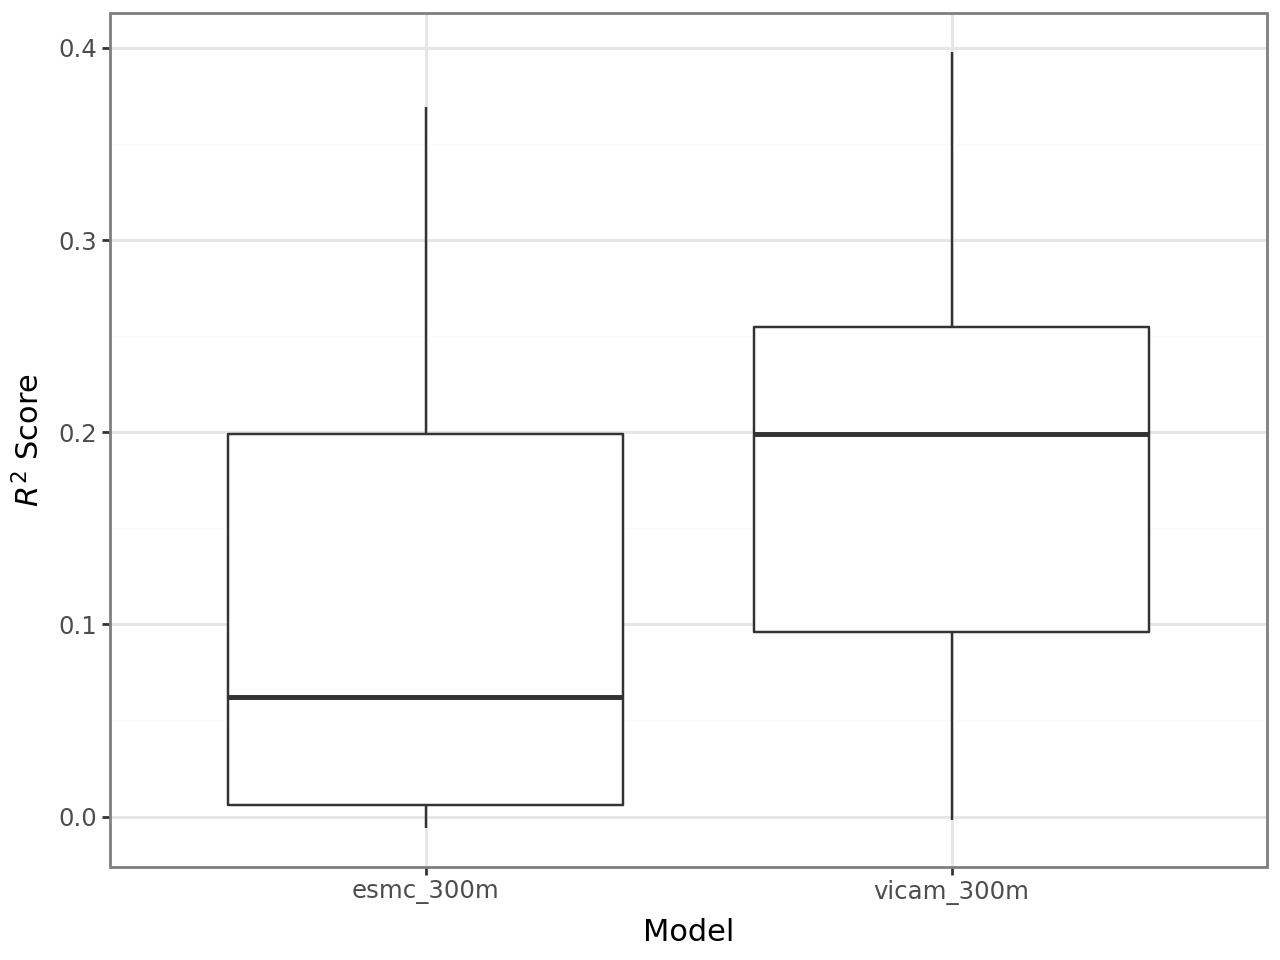

In [67]:
plot = (
    pln.ggplot(full_res, pln.aes(x='Model', y='R2_score_test'))
    + pln.geom_boxplot()
    + pln.theme_bw()
     + pln.labs(
        x='Model', 
        y='$R^2$ Score'
        )
)

plot.save('../experiments/lassoCV_results_boxplot.png', dpi=300)
plot

In [34]:
mean_vican = res_vicam.groupby('dataset', as_index=False)['R2_score_test'].mean()
mean_esmc = res_esmc.groupby('dataset', as_index=False)['R2_score_test'].mean()
grouped_res = mean_vican.merge(mean_esmc, on='dataset', suffixes=('_vicam', '_esmc'))
grouped_res

,dataset,R2_score_test_vicam,R2_score_test_esmc
0,BF520_env_Bloom2018,0.342994,0.280695
1,BG505_env_Bloom2018,0.362235,0.347286
2,CVB3_capsid_MFE_Mattenberger2021,0.071276,0.033596
3,CVB3_capsid_MFElog2_Mattenberger2021,0.183371,0.072559
4,H3N2_NA_fitness_Lei2023,0.171995,0.124462
5,HG_FLU_Bloom2016,0.330190,0.122125
6,HIV1_Rev_SelCoeff_Fernandes2016,0.230538,0.238146
7,HIV1_Tat_SelCoeff_Fernandes2016,0.207007,0.244285
8,OmiXBB15_spike_ACE2bind_Dadonaite2024,0.002713,0.000709
9,OmiXBB15_spike_entry_Dadonaite2024,0.221795,0.000540


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/lassoCV_results_scatter.png
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


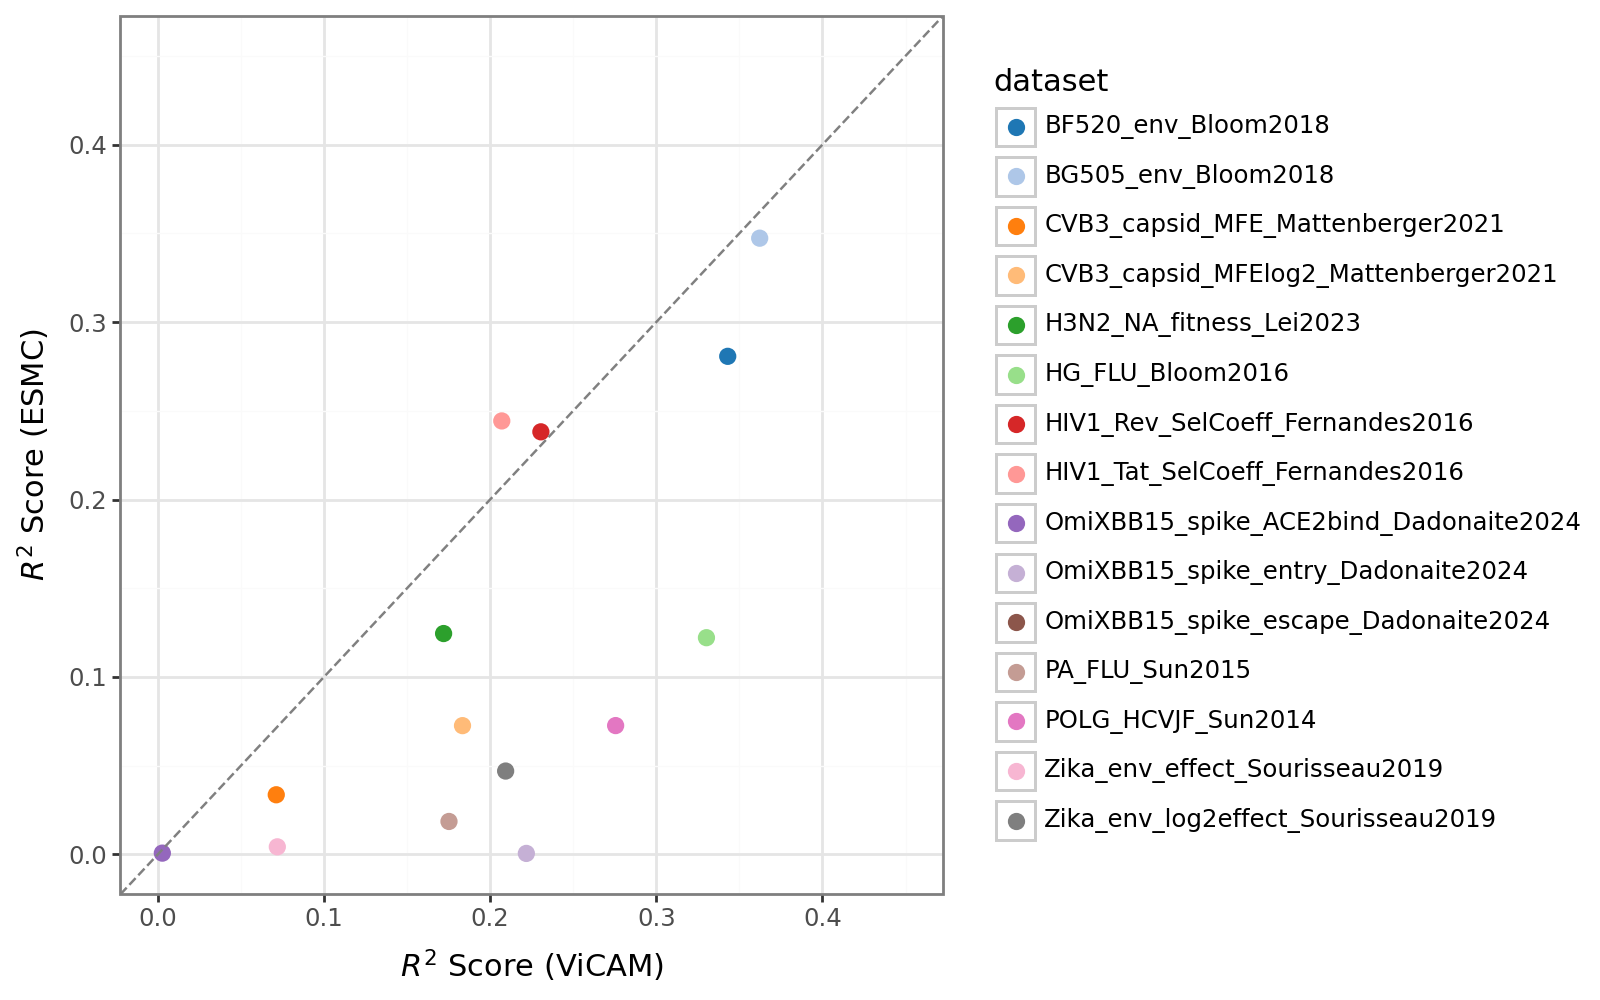

In [68]:
tab20_colors = [
    "#1f77b4", "#aec7e8", "#ff7f0e", "#ffbb78", "#2ca02c",
    "#98df8a", "#d62728", "#ff9896", "#9467bd", "#c5b0d5",
    "#8c564b", "#c49c94", "#e377c2", "#f7b6d2", "#7f7f7f",
    "#c7c7c7", "#bcbd22", "#dbdb8d", "#17becf", "#9edae5"
]


plot = (
    pln.ggplot(grouped_res, pln.aes(x='R2_score_test_vicam', y='R2_score_test_esmc', color='dataset'))
    + pln.geom_point(size=2.5)
    + pln.theme_bw()
    + pln.geom_abline(slope=1, intercept=0, linetype='dashed', color='gray') 
    + pln.ylim(0, 0.45)
    + pln.xlim(0, 0.45)
    + pln.labs(
        x='$R^2$ Score (ViCAM)', 
        y='$R^2$ Score (ESMC)'
        )
    + pln.theme(figure_size=(8, 5))
    + pln.scale_color_manual(values=tab20_colors)

   
)
plot.save('../experiments/lassoCV_results_scatter.png', dpi=300)
plot

# fine tunned esm 3B model from 3rd parties.

In [1]:
from transformers import AutoModel, AutoTokenizer
from transformers import EsmForMaskedLM
from peft import PeftModel, PeftConfig

base_model = EsmForMaskedLM.from_pretrained('facebook/esm2_t36_3B_UR50D')

# Load base model
#base_model = AutoModel.from_pretrained('facebook/esm2_t36_3B_UR50D')

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t36_3B_UR50D')

# Load the PEFT adapter
model = PeftModel.from_pretrained(base_model, '../checkpoints/rsawhney_esm2_3B/')

model.eval()  
model.to('cuda') 

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.74it/s]


PeftModel(
  (base_model): LoraModel(
    (model): EsmForMaskedLM(
      (esm): EsmModel(
        (embeddings): EsmEmbeddings(
          (word_embeddings): Embedding(33, 2560, padding_idx=1)
          (dropout): Dropout(p=0.0, inplace=False)
          (position_embeddings): Embedding(1026, 2560, padding_idx=1)
        )
        (encoder): EsmEncoder(
          (layer): ModuleList(
            (0-35): 36 x EsmLayer(
              (attention): EsmAttention(
                (self): EsmSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=2560, out_features=2560, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Identity()
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=2560, out_features=8, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=8, out_feat

In [2]:
tokens = tokenizer(["AAAAAA", "AAA", "CCCCCCCCCCCC"], return_tensors="pt", padding=True)
tokens

{'input_ids': tensor([[ 0,  5,  5,  5,  5,  5,  5,  2,  1,  1,  1,  1,  1,  1],
        [ 0,  5,  5,  5,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1],
        [ 0, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,  2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [7]:
out = model(**tokens.to('cuda:2'), output_hidden_states=True)
out

MaskedLMOutput(loss=None, logits=tensor([[[ 17.2456,  -5.1442,  -0.7734,  ..., -14.8995, -12.0139,  -5.1289],
         [ -9.4829, -15.0065, -11.5507,  ..., -14.3991, -15.7478, -15.0256],
         [-10.3364, -17.4295, -11.5070,  ..., -14.7070, -15.2455, -17.4757],
         ...,
         [ -9.3040, -16.7838, -10.5673,  ..., -15.2039, -15.2583, -16.7822],
         [ -9.6985, -17.2291, -10.8177,  ..., -15.4338, -15.4110, -17.2378],
         [ -6.5823, -15.1211,  -4.3237,  ..., -14.0038, -14.0910, -15.1330]],

        [[ 16.9105,  -5.6147,   1.0031,  ..., -15.1251, -12.8824,  -5.6492],
         [-10.6330, -15.5865, -12.0240,  ..., -14.5162, -15.4647, -15.5859],
         [-12.9833, -16.6180, -12.1307,  ..., -15.2258, -15.5575, -16.6211],
         ...,
         [ -4.3022, -11.6958,   5.8257,  ..., -13.5188, -13.3907, -11.6959],
         [ -9.4914, -15.5105,  -9.2198,  ..., -15.0236, -15.0091, -15.5159],
         [ -9.1458, -16.3941, -10.6891,  ..., -14.9971, -15.1929, -16.3766]],

        [[ 

In [9]:
out.keys()

odict_keys(['logits', 'hidden_states'])

In [22]:
out['hidden_states'][0][0]

tensor([[-0.0479,  0.0190,  0.0211,  ..., -0.1953,  0.0290,  0.0575],
        [-0.0071, -0.0569, -0.0036,  ..., -0.2342, -0.0971, -0.0631],
        [-0.0071, -0.0569, -0.0036,  ..., -0.2342, -0.0971, -0.0631],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:2')

In [29]:
out.hidden_states[0].shape

torch.Size([3, 14, 2560])

In [31]:
class FastaDataLoader:
    """
    Data loader for reading a FASTA file and creating batches based on a token limit.
    
    Args:
    - fasta_file (str): Path to the FASTA file.
    - batch_token_limit (int, optional): Maximum number of tokens per batch. Defaults to 4096.
    - model (object): Model object with a `_tokenize` method for tokenizing sequences.
    """
    def __init__(self, fasta_file, batch_token_limit=4096):
        self.fasta_file = fasta_file
        self.batch_token_limit = batch_token_limit
        self.sequences = list(SeqIO.parse(fasta_file, "fasta"))
        self.total_sequences = len(self.sequences)
        
        # Check for duplicate sequence labels
        sequence_labels = [seq.id for seq in self.sequences]
        assert len(set(sequence_labels)) == len(sequence_labels), "Found duplicate sequence labels"

    def __len__(self):
        # Approximate total number of batches
        total_tokens = sum(len(str(seq.seq)) + 2 for seq in self.sequences)  # +2 for BOS and EOS tokens
        return (total_tokens + self.batch_token_limit - 1) // self.batch_token_limit

    def __iter__(self):
        ids, lengths, seqs = [], [], []
        current_token_count = 0

        for seq in self.sequences:
            seq_length = len(seq.seq)
            token_count = seq_length + 2  # Include BOS and EOS tokens
            if current_token_count + token_count > self.batch_token_limit and ids:
                # Yield current batch if adding the new sequence exceeds the token limit
                yield ids, lengths, seqs
                ids, lengths, seqs = [], [], []
                current_token_count = 0

            # Add the current sequence to the batch
            ids.append(seq.id)
            lengths.append(seq_length)
            seqs.append(str(seq.seq))
            current_token_count += token_count

        # Yield any remaining sequences
        if ids:
            yield ids, lengths, seqs

In [34]:
from Bio import SeqIO
from tqdm import tqdm
fasta_file = "../test.fasta"
data_loader = FastaDataLoader(fasta_file)
    
for batch_ids, batch_lengths, batch_seqs in tqdm(data_loader, desc="Processing batches", leave=False):
    print(f"Batch IDs: {batch_ids}")
    print(f"Batch Lengths: {batch_lengths}")
    print(f"Batch Sequences: {batch_seqs}")
    # Here you can process the batch with your model

Batch IDs: ['a4', 'a6', 'a10']
Batch Lengths: [4, 6, 10]
Batch Sequences: ['AAAA', 'AAAAAA', 'AAAAAAAAAA']


# Split datasets by site

In [39]:
import pandas as pd
import random

In [3]:
data = pd.read_csv('../data/nonviral/metadata/PABP_YEAST_Fields2013_doubles_metadata.csv', index_col=0)
data

,ID,mutant,target,sequence
0,PABP_DOUBLES_G169V:F170V,G169V:F170V,0.045765,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
1,PABP_DOUBLES_G169A:F170I,G169A:F170I,0.075799,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
2,PABP_DOUBLES_G169C:F170Y,G169C:F170Y,0.700485,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
3,PABP_DOUBLES_G169A:F170S,G169A:F170S,0.061518,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
4,PABP_DOUBLES_G169Q:F170L,G169Q:F170L,0.036095,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
...,...,...,...,...
36516,PABP_DOUBLES_K164N:E175D,K164N:E175D,0.916383,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
36517,PABP_DOUBLES_K164N:E174D,K164N:E174D,0.887493,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
36518,PABP_DOUBLES_K164T:E174D,K164T:E174D,0.902636,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...
36519,PABP_DOUBLES_K164N:F173L,K164N:F173L,0.637755,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...


In [36]:
data['mutant'].str.extract(r'(\d+)').dropna()

,0
0,169
1,169
2,169
3,169
4,169
...,...
36516,164
36517,164
36518,164
36519,164


In [5]:
df = pd.read_csv('../data/nonviral/metadata/PTEN_HUMAN_Fowler2018_metadata.csv', index_col=0)
df

,ID,mutant,target,sequence
0,PTEN_HUMAN_T2A,T2A,0.778594,MAAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
2,PTEN_HUMAN_T2D,T2D,1.173809,MDAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
3,PTEN_HUMAN_T2E,T2E,0.668271,MEAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
5,PTEN_HUMAN_T2G,T2G,0.998143,MGAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
8,PTEN_HUMAN_T2K,T2K,0.896138,MKAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
...,...,...,...,...
8185,PTEN_HUMAN_V403S,V403S,1.032266,MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
8186,PTEN_HUMAN_V403T,V403T,0.974582,MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
8187,PTEN_HUMAN_V403V,V403V,0.722233,MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...
8190,PTEN_HUMAN_V403Y,V403Y,1.170163,MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVY...


In [ ]:
sites = df['mutant'].str.extract(r'(\d+)').dropna()
sites[0].unique().astype(int)

array([  2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  35,  36,  37,  38,  39,  40,  43,  44,  45,  46,
        47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  71,  72,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,
        87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98, 100,
       102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 170,
       171, 172, 174, 175, 176, 177, 178, 179, 182, 184, 186, 187, 188,
       189, 191, 192, 193, 194, 195, 196, 197, 201, 202, 203, 20

In [53]:
df = pd.read_csv('../data/nonviral/metadata/TIM_SULSO_metadata.csv', index_col=0)
print(df.shape)
train_pct=0.8
test_pct=0.2
seed = 42

df["site"] = [int(s[1:-1]) for s in df["mutant"]]
sites = df["site"].unique()
random.seed(seed)
random.shuffle(sites)

if train_pct + test_pct != 1:
    print("Split percentages must sum to 1")
  
df_size = df.shape[0]
df_test_size = df_size*test_pct
test_sites, train_sites = [], []

print(df_size, df_test_size)
# determine sites for test, then train
for site in sites:
    if len(test_sites) <= df_test_size:
        test_sites.extend([mut_site for mut_site in df["site"] if mut_site == site])
    else:
        train_sites.extend([mut_site for mut_site in df["site"] if mut_site == site])


# subset df for train, test data
train_df = df[df["site"].isin(set(train_sites))]
test_df = df[df["site"].isin(set(test_sites))]
test_df

(1519, 4)
1519 303.8


,ID,mutant,target,sequence,site
151,TIM_SULSO_Y52A,Y52A,-1.018648,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,52
152,TIM_SULSO_Y52C,Y52C,-0.487984,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,52
153,TIM_SULSO_Y52D,Y52D,-1.008906,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,52
154,TIM_SULSO_Y52E,Y52E,-0.843564,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,52
155,TIM_SULSO_Y52F,Y52F,0.223149,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,52
...,...,...,...,...,...
1381,TIM_SULSO_N228S,N228S,0.196636,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,228
1382,TIM_SULSO_N228T,N228T,-0.519253,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,228
1383,TIM_SULSO_N228V,N228V,-0.992116,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,228
1384,TIM_SULSO_N228W,N228W,-1.295807,MPRYLKGWLKDVVQLSLRRPSFRASRQRPIISLNERILEFNKRNIT...,228
